# From one U(1)-symmetric gate to the swappy regime

This notebook builds the model from first principles. By the end, you will have verified the conservation law, propagated the paper's localized spin inhomogeneity, and seen why a generalized-SWAP circuit can move information coherently despite strong disorder.

The calculation is deliberately small (`N=8`) so that every cell runs on a laptop. The paper-scale route uses exactly the same functions.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd() / 'src'))

import numpy as np
import matplotlib.pyplot as plt
from swappy import REGIMES, SectorBasis, simulate_trajectory, u1_gate

SEED = 241114357
print('Representative published couplings:', REGIMES)

Representative published couplings: {'localized': 0.395, 'ergodic': 1.374, 'swappy': 2.551, 'near_swap': 3.138}


## 1. The local gate and its invariant

Each gate is the most general two-qubit unitary compatible with total spin-z conservation. The random phases `(h_left, h_right, phi)` are sampled uniformly from `[-pi, pi]`. The interaction strengths `J` and `Jz` are common to the circuit.

At `J=0`, spin exchange is suppressed. At `J=pi`, the mixed-spin block is purely off diagonal: the gate is a generalized SWAP, even though it imprints disorder-dependent phases.

In [2]:
gate = u1_gate(J=REGIMES['swappy'], Jz=np.pi, h_left=0.3, h_right=-1.1, phi=0.7)
charge = np.diag([-1.0, 0.0, 0.0, 1.0])

print('unitarity error =', np.linalg.norm(gate.conj().T @ gate - np.eye(4)))
print('charge-commutator error =', np.linalg.norm(gate @ charge - charge @ gate))

swap_gate = u1_gate(np.pi, np.pi, 0.3, -1.1, 0.7)
print('absolute mixed-spin block at J=pi:\n', np.round(np.abs(swap_gate[1:3, 1:3]), 12))

unitarity error = 1.318651543448113e-16
charge-commutator error = 0.0
absolute mixed-spin block at J=pi:
 [[0. 1.]
 [1. 0.]]


## 2. Work only in the conserved-charge sector

For `M=0`, the Hilbert-space dimension falls from `2^N` to `binom(N, N/2)`. A typical random state is projected to have the central spin up. This is a stochastic trace estimator of the high-temperature spin correlation function discussed in the supplementary material.

In [3]:
basis = SectorBasis(8, magnetization=0)
print(f'full dimension = {2**basis.n_sites}; M=0 dimension = {basis.dimension}')

trajectories = {
    name: simulate_trajectory(8, J, Jz=np.pi, cycles=8, seed=SEED + i)
    for i, (name, J) in enumerate(REGIMES.items())
}
for name, trajectory in trajectories.items():
    conserved = np.max(np.abs(trajectory.magnetization.sum(axis=1)))
    print(f'{name:10s}: max |total M| = {conserved:.2e}')

full dimension = 256; M=0 dimension = 70
localized : max |total M| = 4.16e-16
ergodic   : max |total M| = 2.50e-16
swappy    : max |total M| = 3.33e-16
near_swap : max |total M| = 4.44e-16


## 3. The four dynamical regimes

The same strongly disordered circuit family supports sharply different finite-time behavior as `J` moves along `Jz=pi`:

- **localized:** the inhomogeneity stays near its origin;
- **ergodic:** it spreads and loses its identity;
- **swappy:** a coherent peak moves ballistically, leaves fragments, and later thermalizes;
- **near-SWAP:** an almost intact peak keeps circulating.

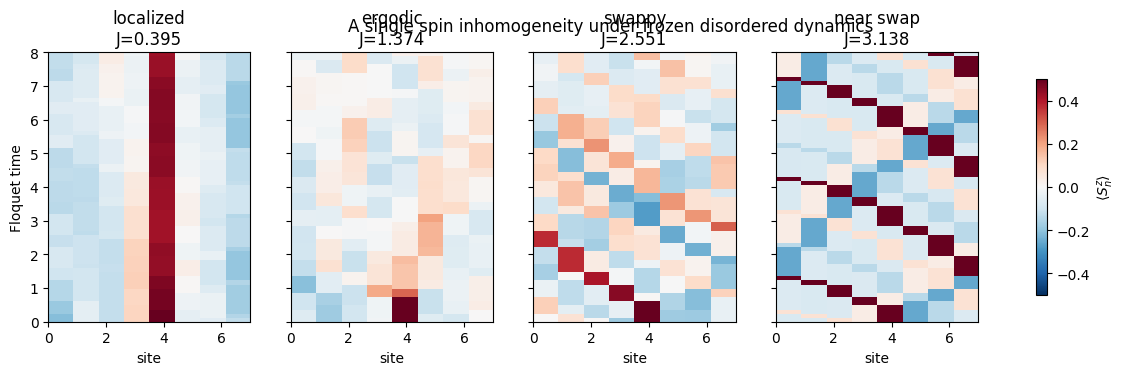

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharex=True, sharey=True)
for axis, (name, trajectory) in zip(axes, trajectories.items()):
    image = axis.imshow(
        trajectory.magnetization,
        origin='lower', aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5,
        extent=(0, 7, 0, trajectory.times[-1]),
    )
    axis.set_title(f"{name.replace('_', ' ')}\nJ={trajectory.metadata['J']:.3f}")
    axis.set_xlabel('site')
axes[0].set_ylabel('Floquet time')
fig.colorbar(image, ax=axes, label=r'$\langle S_n^z\rangle$', shrink=0.8)
fig.suptitle('A single spin inhomogeneity under frozen disordered dynamics')
plt.show()

## What is genuinely Floquet here?

The disorder phases are not scaled down with the kick strength. Near `J=pi`, the circuit sits next to a discrete-time integrable point: generalized SWAP. A small failure to swap leaves a remnant behind at each gate, but the main excitation can remain coherent for a long prethermal window. That neighboring point and its transport channel do not survive the conventional continuous-time Trotter limit.

The next notebook turns these pictures into the paper's experimentally accessible circular statistic.